### Ejercicio 1: Funciones Base de Bernstein

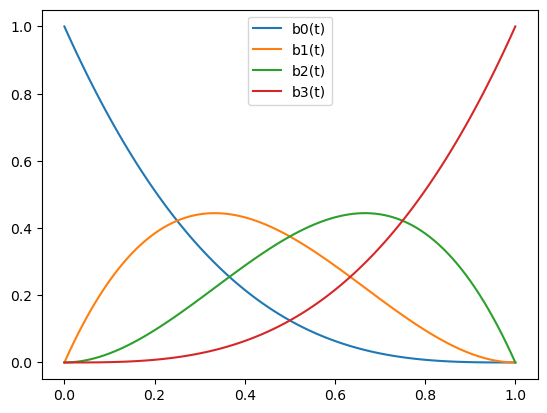

False


In [26]:
# Inciso (a)

import math
import numpy as np
import matplotlib.pyplot as plt
import random

def bernstein3(t):
    matriz = np.zeros((len(t), 4))
    for i in range(len(t)):
        x = t[i]
        b0 = (1-x)**3
        b1 = 3*((1-x)**2)*x
        b2 = 3*(1-x)*(x**2)
        b3 = x**3
        matriz[i][0] = b0
        matriz[i][1] = b1
        matriz[i][2] = b2
        matriz[i][3] = b3

    return matriz

# Inciso (b)

def graficar():
    
    t = np.array([])
    for x in range(101):
        t = np.append(t, x / 100)

    matriz = bernstein3(t)

    ys0 = []
    ys1 = []
    ys2 = []
    ys3 = []

    for i in range(len(matriz)):
        ys0.append(matriz[i][0])
        ys1.append(matriz[i][1])
        ys2.append(matriz[i][2])
        ys3.append(matriz[i][3])



    plt.plot(t, ys0, label = "b0(t)")
    plt.plot(t, ys1,label = "b1(t)")
    plt.plot(t, ys2,label = "b2(t)")
    plt.plot(t, ys3,label = "b3(t)")
    plt.legend()

    plt.show()    


graficar()

# Inciso (c)

def verificacion(matriz):
    
    cumple = True
    for i in range(len(matriz[0])):
        suma = matriz[0][i] + matriz[1][i] + matriz[2][i] + matriz[3][i]
        cumple = np.isclose(suma, 1)
    return cumple

t = np.array([])
for x in range(101):
    t = np.append(t, x / 100)
print(verificacion(bernstein3(t)))


Inciso (d)

Como los coeficientes de la curva de Bezier suman 1, cada punto de control de la curva tiene un "peso" asignadoque funciona como un promedio ponderado entre los puntos. Cada caoeficiente indica cuanto influye cada punto de control en la posición de la curva. Es por esto que la curva queda contenida entre los puntos de control. 

### Ejercicio 2

[[1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [9.70299e-01 2.94030e-02 2.97000e-04 1.00000e-06]
 [9.41192e-01 5.76240e-02 1.17600e-03 8.00000e-06]
 [9.12673e-01 8.46810e-02 2.61900e-03 2.70000e-05]
 [8.84736e-01 1.10592e-01 4.60800e-03 6.40000e-05]
 [8.57375e-01 1.35375e-01 7.12500e-03 1.25000e-04]
 [8.30584e-01 1.59048e-01 1.01520e-02 2.16000e-04]
 [8.04357e-01 1.81629e-01 1.36710e-02 3.43000e-04]
 [7.78688e-01 2.03136e-01 1.76640e-02 5.12000e-04]
 [7.53571e-01 2.23587e-01 2.21130e-02 7.29000e-04]
 [7.29000e-01 2.43000e-01 2.70000e-02 1.00000e-03]
 [7.04969e-01 2.61393e-01 3.23070e-02 1.33100e-03]
 [6.81472e-01 2.78784e-01 3.80160e-02 1.72800e-03]
 [6.58503e-01 2.95191e-01 4.41090e-02 2.19700e-03]
 [6.36056e-01 3.10632e-01 5.05680e-02 2.74400e-03]
 [6.14125e-01 3.25125e-01 5.73750e-02 3.37500e-03]
 [5.92704e-01 3.38688e-01 6.45120e-02 4.09600e-03]
 [5.71787e-01 3.51339e-01 7.19610e-02 4.91300e-03]
 [5.51368e-01 3.63096e-01 7.97040e-02 5.83200e-03]
 [5.31441e-01 3.73977e-01 8.772

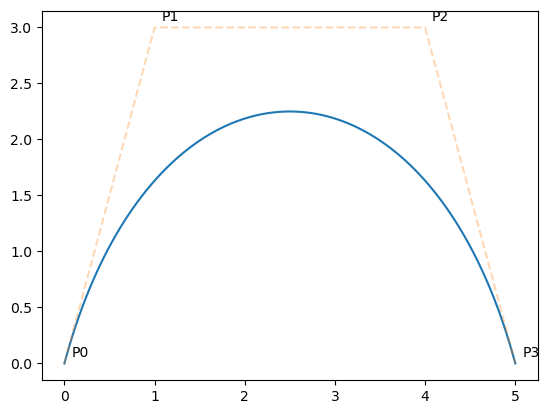

In [27]:

import math
import numpy as np
import matplotlib.pyplot as plt
import random

np.random.seed(42)

# Inciso (a)

t = []
for x in range(101):
    t.append(x / 100)

matriz_A = bernstein3(t)

print(matriz_A)

# Inciso (b)

def P(P1,P2,P3,P4):

    filas_puntos = []
    filas_puntos.append(P1)
    filas_puntos.append(P2)
    filas_puntos.append(P3)
    filas_puntos.append(P4)
    matriz_P = np.array(filas_puntos)
    return matriz_P

matriz_P = P([0,0],[1,3],[4,3],[5,0])
print(matriz_P)

# Inciso (c)

def curva(matriz_A, matriz_P):
    matriz_C = matriz_A @ matriz_P

    return matriz_C

matriz_C = curva(matriz_A, matriz_P)
print(matriz_C)

# Inciso (d)

# Recibe una matriz de los puntos obtenidos de una curva y una matriz de los puntos de control. Con la primera grafica la curva, con la segunda el poligono de control.
def graficar_matriz(matriz_curva, puntos_control):

    xs = []
    ys = []
    for punto in matriz_curva:
        xs.append(punto[0])
        ys.append(punto[1])
        
    plt.plot(xs,ys)

    poligonal_control_x = [puntos_control[0][0], puntos_control[1][0], puntos_control[2][0], puntos_control[3][0]]
    poligonal_control_y = [puntos_control[0][1], puntos_control[1][1], puntos_control[2][1], puntos_control[3][1]]

    # Poligonal de control
    plt.plot(poligonal_control_x, poligonal_control_y, '--', alpha=0.3)

    # Puntos de control (etiquetas)
    for i, (x, y) in enumerate(puntos_control): 
        plt.annotate(f"P{i}", (x, y), textcoords="offset points", xytext=(5, 5))

    #plt.show()
    

graficar_matriz(matriz_C, matriz_P)

Inciso (e)

Matriz A: dimension 100x4

Esta matriz representa los coeficientes del polinomio de Bernstein evaluados en 100 valores de t entre 0 y 1 (equiespaciados). Cada columna representa un coeficiente de Bernstein (b0, b1, b2 y b3) y cada fila es una evaluacion de los cuatro coeficientes para cierto valor t. 

Matriz P: dimension 4x2

Esta matriz representa los 4 puntos de control (uno por fila) de la curva de Bezier. Cada fila contiene 2 coordenadas para dicho punto. 

Matriz C: dimension 100x2

Esta matriz representa 100 puntos de la curva de Bezier (uno pr fila, donde cada fila contiene 2 coordenadas para dicho punto). 

### Ejercicio 3

[[0.         0.        ]
 [0.11041863 0.29964328]
 [0.23412194 0.57788347]
 [0.37012588 0.83472057]
 [0.51744639 1.07015458]
 [0.67509943 1.28418549]
 [0.84210095 1.47681332]
 [1.01746689 1.64803805]
 [1.20021321 1.79785969]
 [1.38935586 1.92627824]
 [1.58391078 2.0332937 ]
 [1.78289393 2.11890606]
 [1.98532125 2.18311534]
 [2.1902087  2.22592152]
 [2.39657223 2.24732461]
 [2.60342777 2.24732461]
 [2.8097913  2.22592152]
 [3.01467875 2.18311534]
 [3.21710607 2.11890606]
 [3.41608922 2.0332937 ]
 [3.61064414 1.92627824]
 [3.79978679 1.79785969]
 [3.98253311 1.64803805]
 [4.15789905 1.47681332]
 [4.32490057 1.28418549]
 [4.48255361 1.07015458]
 [4.62987412 0.83472057]
 [4.76587806 0.57788347]
 [4.88958137 0.29964328]
 [5.         0.        ]]
[[ 4.96714153e-03 -1.38264301e-03]
 [ 1.16895517e-01  3.14873580e-01]
 [ 2.31780406e-01  5.75542102e-01]
 [ 3.85918005e-01  8.42394918e-01]
 [ 5.12751646e-01  1.07558018e+00]
 [ 6.70465253e-01  1.27952820e+00]
 [ 8.44520570e-01  1.45768052e+00]
 [ 1

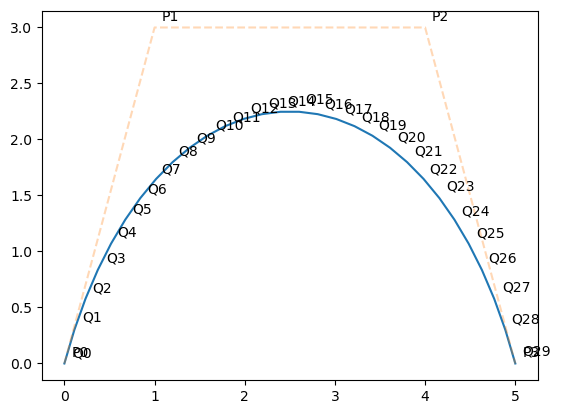

In [28]:

# Inciso (a)

t = []
for x in range(30):
    t.append(x / 29)


# Inciso (b)

matriz_A2 = bernstein3(t)

matriz_P2 = P([0,0], [1,3], [4,3], [5,0])
matriz_C2 = curva(matriz_A2, matriz_P2)

print(matriz_C2)

# Inciso (c)

# Toma una matriz de la curva (puntos observados) y les agrega ruido segun un sigma (controla la desviacion estandar)
def ruido_gaussiano(matriz_C, sigma):
    vector_ruidos = []
    matriz_ruido = matriz_C.copy()
    for i in range(len(matriz_C)):
        ruido_x = np.random.normal(0, sigma)
        ruido_y = np.random.normal(0, sigma)
        vector_ruidos.append([ruido_x,ruido_y])
        matriz_ruido[i] = [matriz_C[i][0]+ruido_x, matriz_C[i][1]+ ruido_y] 
    return matriz_ruido

matriz_ruido = ruido_gaussiano(matriz_C2, 0.01)
print(matriz_ruido)

# Inciso (d)

graficar_matriz(matriz_C2, matriz_P)
for i, (x, y) in enumerate(matriz_ruido): 
        plt.annotate(f"Q{i}", (x, y), textcoords="offset points", xytext=(5, 5))




### Ejercicio 4

In [29]:
#inciso a)

A = bernstein3(t)

#inciso b)

matriz_Q = matriz_ruido.copy()




inciso b) Buscamos la matriz $\hat P \in \mathbb{R}^{4\times 2}$ que minimice el error cuadrático

$$
\hat P = \arg\min_{P \in \mathbb{R}^{4\times 2}}
\|AP-Q\|_F^2.
$$

Sea

$$
Q =
\begin{bmatrix}
q_1 & q_2
\end{bmatrix},
\qquad
P =
\begin{bmatrix}
p_1 & p_2
\end{bmatrix},
$$

donde $q_1,q_2 \in \mathbb{R}^{m}$ y $p_1,p_2 \in \mathbb{R}^{4}$.

Entonces

$$
AP-Q
=
\begin{bmatrix}
Ap_1-q_1 & Ap_2-q_2
\end{bmatrix}.
$$

Como la norma de Frobenius al cuadrado es la suma de los cuadrados de todas las entradas,

$$
\|AP-Q\|_F^2
=
\|Ap_1-q_1\|^2
+
\|Ap_2-q_2\|^2.
$$

Por lo tanto, el problema se descompone en dos problemas independientes de mínimos cuadrados:

$$
\min_{p_1}\|Ap_1-q_1\|^2,
\qquad
\min_{p_2}\|Ap_2-q_2\|^2.
$$

Para cada columna, la condición de optimalidad viene dada por las ecuaciones normales

$$
A^T(Ap_i-q_i)=0,
$$

es decir,

$$
A^TAp_i=A^Tq_i,
\qquad i=1,2.
$$

Agrupando ambas ecuaciones en forma matricial obtenemos

$$
A^TAP=A^TQ.
$$

Si $A^TA$ es invertible, la solución es

$$
\hat P=(A^TA)^{-1}A^TQ.
$$

[[6.37720785e-03 4.95044917e-03]
 [9.85364575e-01 2.98971294e+00]
 [4.00232683e+00 2.99283736e+00]
 [4.99953692e+00 4.94987417e-03]]


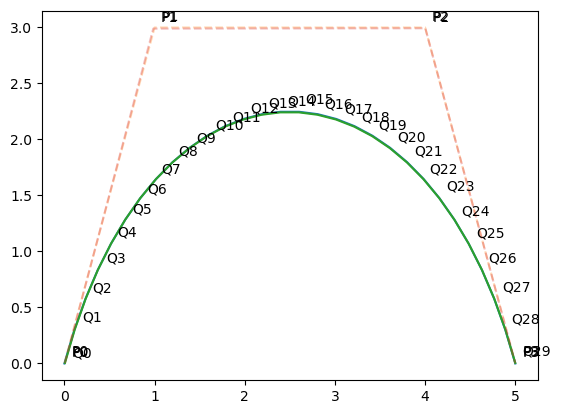

In [51]:
#inciso (c)
def ec_normal(A, matriz_Q):
    A_traspuesta = A.T
    matriz_producto = A_traspuesta @ A

    inversa = np.linalg.inv(matriz_producto)

    matriz_P_sombrero = (inversa @ A_traspuesta) 
    matriz_P_sombrero = matriz_P_sombrero @ matriz_Q

    #print(np.linalg.det(A.T @ A)) #Te dice el valor del determinante

    return matriz_P_sombrero


matriz_puntos_ajustados = ec_normal(A, matriz_Q)
matriz_curva_ajustada = A @ matriz_puntos_ajustados

print(ec_normal(A, matriz_Q))

#inciso (d)
graficar_matriz(matriz_C2, matriz_P)
graficar_matriz(matriz_curva_ajustada, matriz_puntos_ajustados)
for i, (x, y) in enumerate(matriz_ruido): 
        plt.annotate(f"Q{i}", (x, y), textcoords="offset points", xytext=(5, 5))


Inciso (e)

No, los puntos de control estimados no son exactamente iguales a los originales porque trabajamos con puntos de la curva a los que les agregamos ruido. Al hacer el ajuste, el algoritmo intenta encontrar los puntos de control que mejor reproduzcan esos datos modificados, por lo que obtiene valores parecidos a los originales, pero no exactamente iguales.

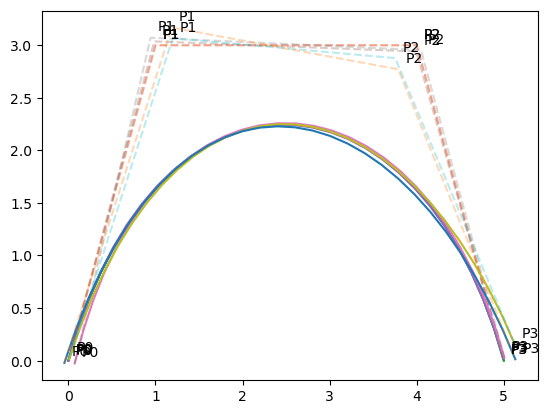

In [52]:

# Inciso (f)

sigmas = [0.00, 0.02, 0.05, 0.10, 0.20]

matriz_ruido_1 = ruido_gaussiano(matriz_C2, sigmas[0])
matriz_ruido_2 = ruido_gaussiano(matriz_C2, sigmas[1])
matriz_ruido_3 = ruido_gaussiano(matriz_C2, sigmas[2])
matriz_ruido_4 = ruido_gaussiano(matriz_C2, sigmas[3])
matriz_ruido_5 = ruido_gaussiano(matriz_C2, sigmas[4])

# Inciso (g)

matriz_pc_ajustados1 = ec_normal(A, matriz_ruido_1)
matriz_pc_ajustados2 = ec_normal(A, matriz_ruido_2)
matriz_pc_ajustados3 = ec_normal(A, matriz_ruido_3)
matriz_pc_ajustados4 = ec_normal(A, matriz_ruido_4)
matriz_pc_ajustados5 = ec_normal(A, matriz_ruido_5)

matriz_curva_ajustada1 = A @ matriz_pc_ajustados1
matriz_curva_ajustada2 = A @ matriz_pc_ajustados2
matriz_curva_ajustada3 = A @ matriz_pc_ajustados3
matriz_curva_ajustada4 = A @ matriz_pc_ajustados4
matriz_curva_ajustada5 = A @ matriz_pc_ajustados5

graficar_matriz(matriz_C2, matriz_P)
graficar_matriz(matriz_curva_ajustada1, matriz_pc_ajustados1)
graficar_matriz(matriz_curva_ajustada2, matriz_pc_ajustados2)
graficar_matriz(matriz_curva_ajustada3, matriz_pc_ajustados3)
graficar_matriz(matriz_curva_ajustada4, matriz_pc_ajustados4)
graficar_matriz(matriz_curva_ajustada5, matriz_pc_ajustados5)

plt.show()






In [53]:
# Inciso (h)

errores = []
curvas_ajustadas = [matriz_curva_ajustada1,matriz_curva_ajustada2, matriz_curva_ajustada3, matriz_curva_ajustada4, matriz_curva_ajustada5]

for i in range(len(curvas_ajustadas)):
    resta = matriz_C2 - curvas_ajustadas[i]
    matriz_al_cuadrado = resta**2
    
    ECM = (np.sum(matriz_al_cuadrado))*(1/len(matriz_C2))
    errores.append(ECM)
    print("Sigma = ", sigmas[i], "    ", "ECM: ", ECM)


Sigma =  0.0      ECM:  3.892901993345551e-30
Sigma =  0.02      ECM:  0.00010024283514792004
Sigma =  0.05      ECM:  0.0007654021499160368
Sigma =  0.1      ECM:  0.0042843031380027504
Sigma =  0.2      ECM:  0.0029939079858036324


Se observa que el ECM aumenta al aumentar σ. Esto era esperable, ya que un mayor nivel de ruido implica una mayor desviación respecto de los datos originales, lo que empeora la calidad del ajuste.


- La curva ajustada suele seguir recuperando la forma general de la curva original, especialmente para valores moderados de σ.
- Sin embargo, el ajuste es menos preciso y pueden aparecer pequeñas deformaciones respecto de la curva original.
- Los puntos de control estimados se alejan más de los puntos de control originales, es decir, la estimación de esos puntos es menos exacta.



### Ejercicio 5

$$
\begin{aligned}
E(p)
&= \|Ap-q\|^2 \\
&= (Ap-q) \cdot (Ap-q) \\
\end{aligned}

$$
Como Ap-q es un vector, lo podemos trasponer para el producto vectorial consigo mismo 
$$

\begin{aligned}
&= (Ap-q)^T(Ap-q) \\
&= (Ap)^T(Ap) - (Ap)^Tq - q^T(Ap) + q^Tq \\
&= p^TA^TAp - p^TA^Tq - q^TAp + q^Tq.
\end{aligned}
$$

Además, como $$ (p^TA^Tq) $$ es un escalar, podemos trasponerlo

$$
p^TA^Tq = (p^TA^Tq)^T = q^TAp.
$$

Por lo tanto,

$$
\begin{aligned}
E(p)
&= p^TA^TAp - q^TAp - q^TAp + q^Tq \\
&= p^TA^TAp - 2q^TAp + q^Tq.
\end{aligned}
$$

En conclusión,

$$
E(p)=p^TA^TAp-2q^TAp+q^Tq.
$$

Inciso (b)

\begin{aligned}
E(p) 
&= \|Ap-q\|^2 \\
&= (Ap-q)^2 \\
&= (Ap)^2 - 2Apq + q^2  \\

\end{aligned}


Las partes cuadráticas son el primer término (tienen las variable p dos veces, grado 2 de la variable p en $E(p)$ ).

Cuando hablamos de "parte cuadrática" nos referimos a los términos que tienen a la variable p multiplicándose consigo misma.
$$
E(p)=p^TA^TAp-2q^TAp+q^Tq.
$$

La expresión está compuesta por tres tipos de términos:

- $p^T A^T A p$: término cuadrático en $p$.
- $-2q^T A p$: término lineal en $p$.
- $q^T q$: término constante.


Por lo tanto, la parte cuadrática de $E(p)$ es

$$
p^TA^TAp.
$$

In [70]:
# Inciso (c)

simetria1 = (A.T @ (A)).T
simetria2 = (A.T) @ (A)

if(np.allclose(simetria1, simetria2)):
    print("Son simetricas")

Son simetricas


In [71]:
# Inciso (d)

autovalores, autovectores = np.linalg.eig(A.T @ A)
print("Autovalores de A^T * A: ", autovalores, "\n")
print("Autovectores de A^T * A: \n", autovectores)

Autovalores de A^T * A:  [7.51154315 4.8161144  1.70568592 0.25824389] 

Autovectores de A^T * A: 
 [[ 0.52179727  0.67835134  0.47720814 -0.19959826]
 [ 0.47720814  0.19959826 -0.52179727  0.67835134]
 [ 0.47720814 -0.19959826 -0.52179727 -0.67835134]
 [ 0.52179727 -0.67835134  0.47720814  0.19959826]]


Inciso (e)

Todos los autovalores de $$ A^T * A\ $$ son positivos. Esto indica que la parte cuadrática de la función de error es definida positiva, por lo que E(p) es una función convexa con forma de cuenco y posee un único mínimo global.

### Ejercicio 6

In [ ]:
# Inciso (a)

def gradiente(p, A, q):
    res = 2*(A.T)*((A@p)-q)
    return res

# Inciso (b)
